#### zero_rate

In [3]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse

# 读取你的数据
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/output_0121/Big-atlas-withlevel3-human_withUMAP2.h5ad")

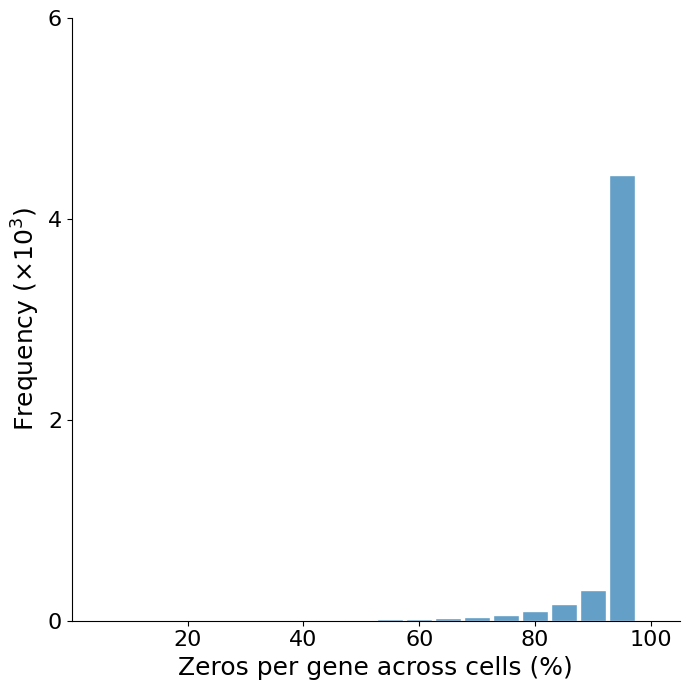

In [12]:
# 计算每个基因的零值率（百分比）
if sparse.issparse(adata.X):
    zero_count = adata.n_obs - np.array((adata.X != 0).sum(axis=0)).flatten()
else:
    zero_count = (adata.X == 0).sum(axis=0)
zero_rate = np.array(zero_count).flatten() / adata.n_obs * 100
# 分箱：0-100%，每5%一个bin（和论文图的柱子密度匹配）
bins = np.arange(0, 101, 5)
# 统计每个bin内的基因数量
frequency, bin_edges = np.histogram(zero_rate, bins=bins)
plt.figure(figsize=(7, 7), dpi=100)

# 绘制柱状图
plt.bar(
    x=bin_edges[:-1],  # 每个bin的左边界
    height=frequency/10000,  # 除以1000，匹配论文Y轴×10³的标注
    width=4.5,  # 柱子宽度，避免重叠
    color="#639fc7",  # 匹配论文的蓝色
    edgecolor="white"
)

# 坐标轴设置（完全匹配论文）
plt.xlabel("Zeros per gene across cells (%)", fontsize=18)
plt.ylabel("Frequency ($\\times 10^3$)", fontsize=18)
plt.xlim(0, 105)
plt.xticks([20, 40, 60, 80, 100], fontsize=16)
plt.yticks([0, 2, 4, 6], fontsize=16)

# 去掉上/右边框，匹配论文简洁风格
plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
adata_mouse = sc.read_h5ad("/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/output_0121/Big-atlas-withlevel3-mouse_withUMAP2.h5ad")

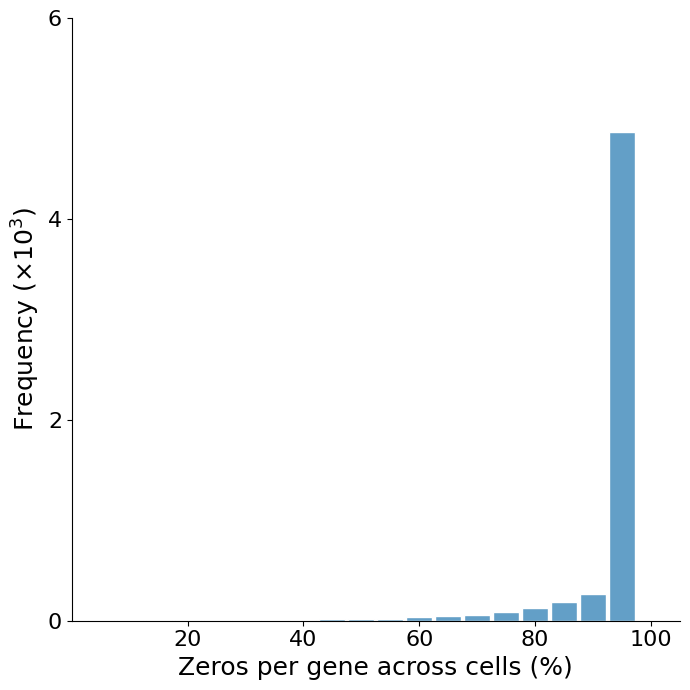

In [15]:
# 计算每个基因的零值率（百分比）
if sparse.issparse(adata_mouse.X):
    zero_count = adata_mouse.n_obs - np.array((adata_mouse.X != 0).sum(axis=0)).flatten()
else:
    zero_count = (adata_mouse.X == 0).sum(axis=0)
zero_rate = np.array(zero_count).flatten() / adata_mouse.n_obs * 100
# 分箱：0-100%，每5%一个bin（和论文图的柱子密度匹配）
bins = np.concatenate([np.arange(0, 100, 5), [100]])
# 统计每个bin内的基因数量
frequency, bin_edges = np.histogram(zero_rate, bins=bins)
plt.figure(figsize=(7, 7), dpi=100)

# 绘制柱状图
plt.bar(
    x=bin_edges[:-1],  # 每个bin的左边界
    height=frequency/10000,  # 除以1000，匹配论文Y轴×10³的标注
    width=4.5,  # 柱子宽度，避免重叠
    color="#639fc7",  # 匹配论文的蓝色
    edgecolor="white"
)

# 坐标轴设置（完全匹配论文）
plt.xlabel("Zeros per gene across cells (%)", fontsize=18)
plt.ylabel("Frequency ($\\times 10^3$)", fontsize=18)
plt.xlim(0, 105)
plt.xticks([20, 40, 60, 80, 100], fontsize=16)
plt.yticks([0, 2, 4, 6], fontsize=16)

# 去掉上/右边框，匹配论文简洁风格
plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

#### heatmap

正在读取 SEG 文件: /home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_results/human_SEG_result.csv ...
  成功读取 2176 个 SEG 基因。

正在加载单细胞数据: /home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/output_0121/Big-atlas-withlevel3-human_withUMAP2.h5ad ...


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


  数据中匹配到 2164 个 SEG，0 个 HKG。

正在进行标准化...


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


正在计算伪 Bulk (Pseudo-bulk)...


/tmp/ipykernel_1390732/2368726511.py:106: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pb_df = expr_df.groupby(TISSUE_COL_IN_H5AD).mean()


正在进行 Z-score 标准化...

正在绘制热图...

成功！图片已保存为: human_SEG_heatmap.png


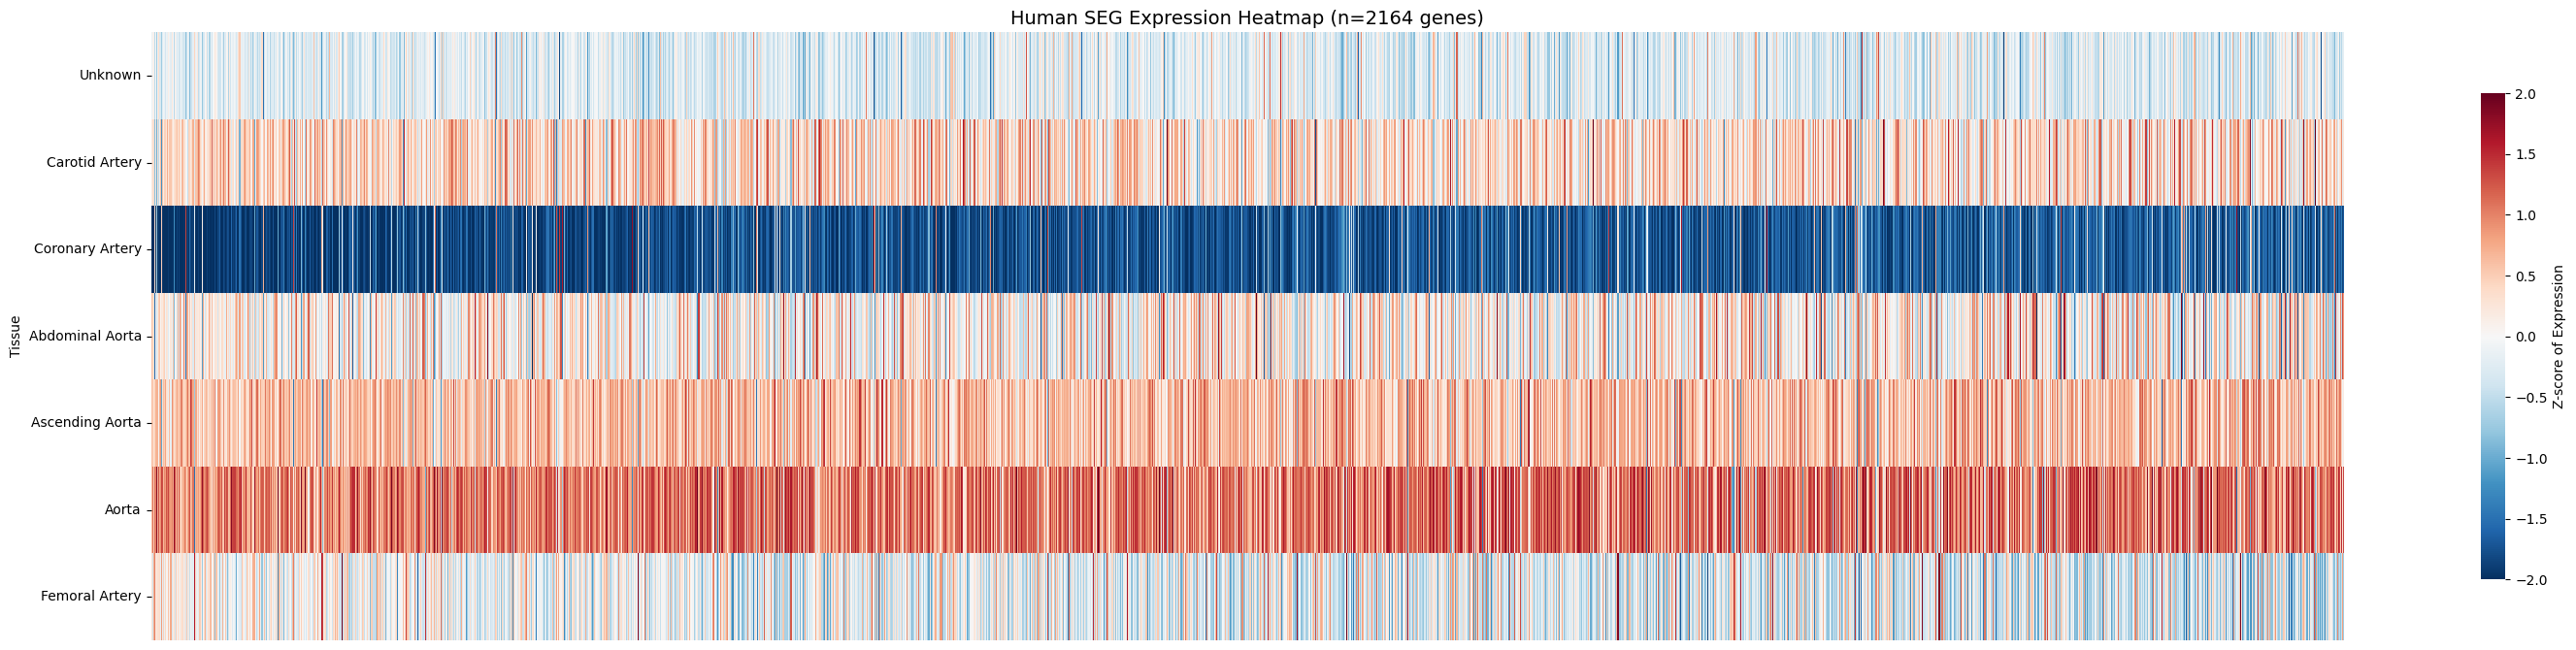

In [3]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# ====================== 【核心配置区】请修改这里 ======================
# 1. 文件路径
PATH_H5AD = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/output_0121/Big-atlas-withlevel3-human_withUMAP2.h5ad"
PATH_SEG = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_results/human_SEG_result.csv"
SPECIES = "Human"  # 这里写 "Human" 或 "human" 都可以

# 2. SEG 文件读取设置
SEG_FILE_COLUMN = "gene"

# 3. 数据中的列名
TISSUE_COL_IN_H5AD = "tissue"

# 4. 对照用的 HKG 列表
HKG_LIST = []
# =====================================================================

# ---------------------- 步骤 1: 读取 SEG 基因列表 ----------------------
print(f"正在读取 SEG 文件: {PATH_SEG} ...")

def read_gene_list(file_path, col_name):
    ext = os.path.splitext(file_path)[1].lower()
    if ext in ['.csv']:
        df = pd.read_csv(file_path)
    elif ext in ['.txt', '.tsv']:
        df = pd.read_csv(file_path, sep='\t')
    elif ext in ['.xlsx', '.xls']:
        df = pd.read_excel(file_path)
    else:
        raise ValueError("不支持的文件格式，请使用 CSV, TXT 或 Excel")
    
    if col_name is None:
        return df.iloc[:, 0].astype(str).unique().tolist()
    else:
        return df[col_name].astype(str).unique().tolist()

SEG_LIST = read_gene_list(PATH_SEG, SEG_FILE_COLUMN)
print(f"  成功读取 {len(SEG_LIST)} 个 SEG 基因。")

# 【修复】基因名大小写校正 (自动处理 species 的大小写)
species_lower = SPECIES.lower()
if species_lower == "human":
    SEG_LIST = [g.upper() for g in SEG_LIST]
    HKG_LIST = [g.upper() for g in HKG_LIST]
else:
    SEG_LIST = [g.capitalize() for g in SEG_LIST]
    HKG_LIST = [g.capitalize() for g in HKG_LIST]

# ---------------------- 步骤 2: 加载并处理 h5ad 数据 ----------------------
print(f"\n正在加载单细胞数据: {PATH_H5AD} ...")
adata = sc.read(PATH_H5AD)

# 合并最终基因列表
ALL_GENES = SEG_LIST + HKG_LIST

# 检查基因在数据中是否存在，并过滤
def filter_genes(adata, gene_list):
    exist_mask = adata.var_names.isin(gene_list)
    exist_genes = adata.var_names[exist_mask].tolist()
    
    seg_found = [g for g in gene_list if g in exist_genes and g in SEG_LIST]
    hkg_found = [g for g in gene_list if g in exist_genes and g in HKG_LIST]
    
    print(f"  数据中匹配到 {len(seg_found)} 个 SEG，{len(hkg_found)} 个 HKG。")
    return seg_found, hkg_found

SEG_FOUND, HKG_FOUND = filter_genes(adata, ALL_GENES)
ALL_GENES_FOUND = SEG_FOUND + HKG_FOUND

if len(SEG_FOUND) == 0:
    raise ValueError("错误：没有在数据中找到任何 SEG 基因，请检查基因名格式是否匹配！")

# 提取数据子集
adata_sub = adata[:, ALL_GENES_FOUND].copy()

# 标准化
print("\n正在进行标准化...")
sc.pp.normalize_total(adata_sub, target_sum=1e6)
sc.pp.log1p(adata_sub)

# 过滤低质量组织 (细胞数 < 10)
tissue_counts = adata_sub.obs[TISSUE_COL_IN_H5AD].value_counts()
keep_tissues = tissue_counts[tissue_counts >= 10].index
adata_sub = adata_sub[adata_sub.obs[TISSUE_COL_IN_H5AD].isin(keep_tissues)]

# ---------------------- 步骤 3: 计算伪 Bulk 与 Z-score ----------------------
print("正在计算伪 Bulk (Pseudo-bulk)...")

# 转成DataFrame
expr_df = pd.DataFrame(
    adata_sub.X.toarray() if hasattr(adata_sub.X, "toarray") else adata_sub.X,
    index=adata_sub.obs_names,
    columns=adata_sub.var_names
)

# 加上tissue信息
expr_df[TISSUE_COL_IN_H5AD] = adata_sub.obs[TISSUE_COL_IN_H5AD].values

# 按tissue取平均
pb_df = expr_df.groupby(TISSUE_COL_IN_H5AD).mean()

# 去掉tissue列（如果还在的话）
if TISSUE_COL_IN_H5AD in pb_df.columns:
    pb_df = pb_df.drop(columns=[TISSUE_COL_IN_H5AD])

# Z-score 标准化 (按基因列)
print("正在进行 Z-score 标准化...")
z_df = (pb_df - pb_df.mean()) / pb_df.std()

# ====================== 【核心修改】这里不再使用预设顺序 ======================
# 直接按数据中组织的细胞数量从多到少排序 (这样热图从上到下是主要组织到次要组织)
final_tissue_order = tissue_counts.index.tolist()
# 确保只保留在 z_df 中存在的组织 (防止过滤低质量组织后索引对不上)
final_tissue_order = [t for t in final_tissue_order if t in z_df.index]

z_df = z_df.loc[final_tissue_order, ALL_GENES_FOUND]
# ===============================================================================

# ---------------------- 步骤 4: 绘制热图 ----------------------
print("\n正在绘制热图...")

n_genes = len(ALL_GENES_FOUND)
n_tissues = len(z_df.index)

# 动态调整图片大小
fig_width = min(30, 8 + n_genes * 0.15) 
fig_height = min(12, 4 + n_tissues * 0.4)

plt.figure(figsize=(fig_width, fig_height))
ax = plt.gca()

# 绘制热图
sns.heatmap(
    z_df,
    ax=ax,
    cmap="RdBu_r",
    center=0,
    vmin=-2, vmax=2,
    cbar_kws={"label": "Z-score of Expression", "shrink": 0.8},
    
    yticklabels=True,
    xticklabels=False if n_genes > 50 else True
)

ax.set_title(f"{SPECIES.capitalize()} SEG Expression Heatmap (n={len(SEG_FOUND)} genes)", fontsize=14)
ax.set_ylabel("Tissue")

plt.tight_layout()

# 保存图片
output_name = f"{species_lower}_SEG_heatmap.png"
plt.savefig(output_name, dpi=300, bbox_inches="tight")
print(f"\n成功！图片已保存为: {output_name}")

plt.show()

正在读取 SEG 文件: /home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_results/mouse_SEG_result.csv ...
  成功读取 3277 个 SEG 基因。

正在加载单细胞数据: /home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/output_0121/Big-atlas-withlevel3-mouse_withUMAP2.h5ad ...


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


  数据中匹配到 3235 个 SEG，0 个 HKG。

正在进行标准化...


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


正在计算伪 Bulk (Pseudo-bulk)...


/tmp/ipykernel_1390732/1062233472.py:107: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pb_df = expr_df.groupby(TISSUE_COL_IN_H5AD).mean()


正在进行 Z-score 标准化...

正在绘制热图...

成功！图片已保存为: mouse_SEG_heatmap.png


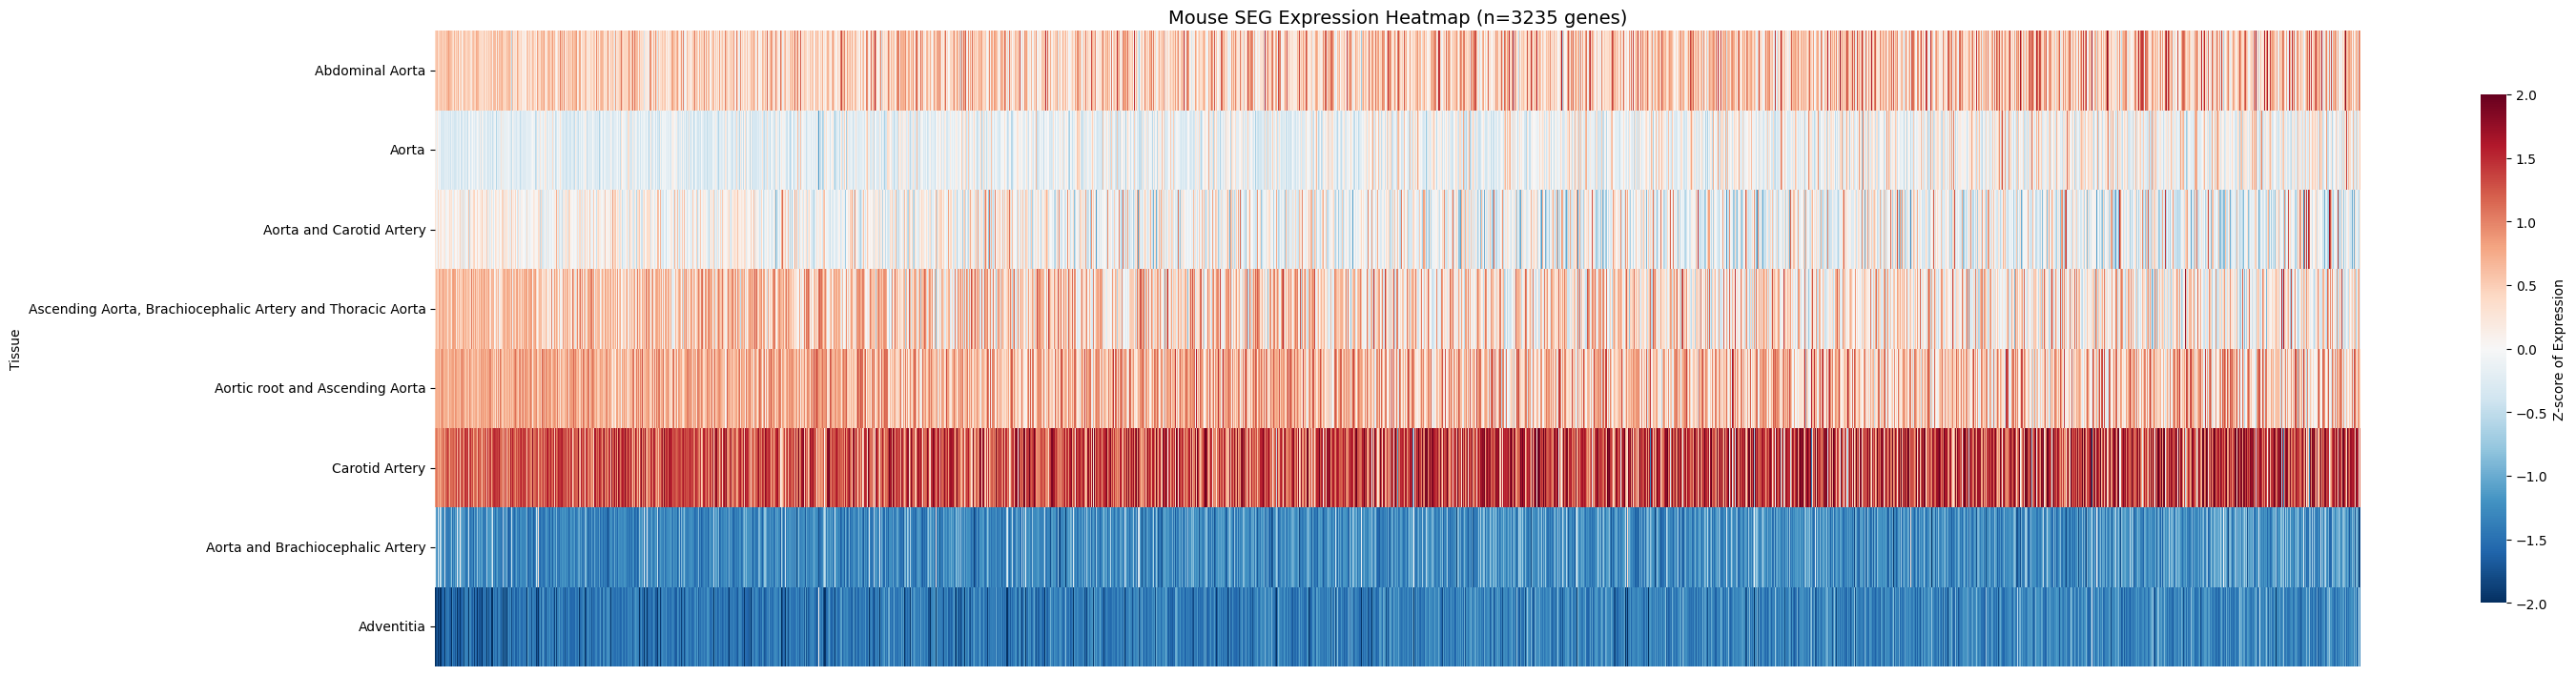

In [4]:
####mouse
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# ====================== 【核心配置区】请修改这里 ======================
# 1. 文件路径
PATH_H5AD = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/output_0121/Big-atlas-withlevel3-mouse_withUMAP2.h5ad"
PATH_SEG = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_results/mouse_SEG_result.csv"
SPECIES = "Mouse"  # 这里写 "Human" 或 "human" 都可以

# 2. SEG 文件读取设置
SEG_FILE_COLUMN = "gene"

# 3. 数据中的列名
TISSUE_COL_IN_H5AD = "tissue"

# 4. 对照用的 HKG 列表
HKG_LIST = []
# =====================================================================

# ---------------------- 步骤 1: 读取 SEG 基因列表 ----------------------
print(f"正在读取 SEG 文件: {PATH_SEG} ...")

def read_gene_list(file_path, col_name):
    ext = os.path.splitext(file_path)[1].lower()
    if ext in ['.csv']:
        df = pd.read_csv(file_path)
    elif ext in ['.txt', '.tsv']:
        df = pd.read_csv(file_path, sep='\t')
    elif ext in ['.xlsx', '.xls']:
        df = pd.read_excel(file_path)
    else:
        raise ValueError("不支持的文件格式，请使用 CSV, TXT 或 Excel")
    
    if col_name is None:
        return df.iloc[:, 0].astype(str).unique().tolist()
    else:
        return df[col_name].astype(str).unique().tolist()

SEG_LIST = read_gene_list(PATH_SEG, SEG_FILE_COLUMN)
print(f"  成功读取 {len(SEG_LIST)} 个 SEG 基因。")

# 【修复】基因名大小写校正 (自动处理 species 的大小写)
species_lower = SPECIES.lower()
if species_lower == "human":
    SEG_LIST = [g.upper() for g in SEG_LIST]
    HKG_LIST = [g.upper() for g in HKG_LIST]
else:
    SEG_LIST = [g.capitalize() for g in SEG_LIST]
    HKG_LIST = [g.capitalize() for g in HKG_LIST]

# ---------------------- 步骤 2: 加载并处理 h5ad 数据 ----------------------
print(f"\n正在加载单细胞数据: {PATH_H5AD} ...")
adata = sc.read(PATH_H5AD)

# 合并最终基因列表
ALL_GENES = SEG_LIST + HKG_LIST

# 检查基因在数据中是否存在，并过滤
def filter_genes(adata, gene_list):
    exist_mask = adata.var_names.isin(gene_list)
    exist_genes = adata.var_names[exist_mask].tolist()
    
    seg_found = [g for g in gene_list if g in exist_genes and g in SEG_LIST]
    hkg_found = [g for g in gene_list if g in exist_genes and g in HKG_LIST]
    
    print(f"  数据中匹配到 {len(seg_found)} 个 SEG，{len(hkg_found)} 个 HKG。")
    return seg_found, hkg_found

SEG_FOUND, HKG_FOUND = filter_genes(adata, ALL_GENES)
ALL_GENES_FOUND = SEG_FOUND + HKG_FOUND

if len(SEG_FOUND) == 0:
    raise ValueError("错误：没有在数据中找到任何 SEG 基因，请检查基因名格式是否匹配！")

# 提取数据子集
adata_sub = adata[:, ALL_GENES_FOUND].copy()

# 标准化
print("\n正在进行标准化...")
sc.pp.normalize_total(adata_sub, target_sum=1e6)
sc.pp.log1p(adata_sub)

# 过滤低质量组织 (细胞数 < 10)
tissue_counts = adata_sub.obs[TISSUE_COL_IN_H5AD].value_counts()
keep_tissues = tissue_counts[tissue_counts >= 10].index
adata_sub = adata_sub[adata_sub.obs[TISSUE_COL_IN_H5AD].isin(keep_tissues)]

# ---------------------- 步骤 3: 计算伪 Bulk 与 Z-score ----------------------
print("正在计算伪 Bulk (Pseudo-bulk)...")

# 转成DataFrame
expr_df = pd.DataFrame(
    adata_sub.X.toarray() if hasattr(adata_sub.X, "toarray") else adata_sub.X,
    index=adata_sub.obs_names,
    columns=adata_sub.var_names
)

# 加上tissue信息
expr_df[TISSUE_COL_IN_H5AD] = adata_sub.obs[TISSUE_COL_IN_H5AD].values

# 按tissue取平均
pb_df = expr_df.groupby(TISSUE_COL_IN_H5AD).mean()

# 去掉tissue列（如果还在的话）
if TISSUE_COL_IN_H5AD in pb_df.columns:
    pb_df = pb_df.drop(columns=[TISSUE_COL_IN_H5AD])

# Z-score 标准化 (按基因列)
print("正在进行 Z-score 标准化...")
z_df = (pb_df - pb_df.mean()) / pb_df.std()

# ====================== 【核心修改】这里不再使用预设顺序 ======================
# 直接按数据中组织的细胞数量从多到少排序 (这样热图从上到下是主要组织到次要组织)
final_tissue_order = tissue_counts.index.tolist()
# 确保只保留在 z_df 中存在的组织 (防止过滤低质量组织后索引对不上)
final_tissue_order = [t for t in final_tissue_order if t in z_df.index]

z_df = z_df.loc[final_tissue_order, ALL_GENES_FOUND]
# ===============================================================================

# ---------------------- 步骤 4: 绘制热图 ----------------------
print("\n正在绘制热图...")

n_genes = len(ALL_GENES_FOUND)
n_tissues = len(z_df.index)

# 动态调整图片大小
fig_width = min(30, 8 + n_genes * 0.15) 
fig_height = min(12, 4 + n_tissues * 0.4)

plt.figure(figsize=(fig_width, fig_height))
ax = plt.gca()

# 绘制热图
sns.heatmap(
    z_df,
    ax=ax,
    cmap="RdBu_r",
    center=0,
    vmin=-2, vmax=2,
    cbar_kws={"label": "Z-score of Expression", "shrink": 0.8},
    
    yticklabels=True,
    xticklabels=False if n_genes > 50 else True
)

ax.set_title(f"{SPECIES.capitalize()} SEG Expression Heatmap (n={len(SEG_FOUND)} genes)", fontsize=14)
ax.set_ylabel("Tissue")

plt.tight_layout()

# 保存图片
output_name = f"{species_lower}_SEG_heatmap.png"
plt.savefig(output_name, dpi=300, bbox_inches="tight")
print(f"\n成功！图片已保存为: {output_name}")

plt.show()

In [ ]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
from scipy import sparse
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# scCompass Figure 3e / S4 风格复刻版
# 论文方法：
# single-cell raw counts
# -> pseudo-bulk by organ/tissue
# -> FPKM
# -> heatmap of SEGs and HKGs across top 10 organs
# =========================================================

# -------------------------------
# 配置区：按你的文件修改
# -------------------------------
PATH_H5AD = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/output_0121/Big-atlas-withlevel3-human_withUMAP2.h5ad"
PATH_SEG = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_results/human_SEG_result.csv"
PATH_HKG = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/SEGs/Housekeeping_GenesHuman.csv"
PATH_GENE_LENGTH = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/SEGs/FPKM/human_gene_length.tsv"

SPECIES = "human"   # human / mouse
TISSUE_COL = "tissue"
SEG_COL = "gene"

# HKG 文件设置
HKG_SEP = ";"
HKG_COL = None   # None = 自动猜测

# top 10 tissues：论文用于热图评估的是 top 10 organs
TOP_N_TISSUES = 10

# 输出目录
OUTDIR = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_heatmap"
os.makedirs(OUTDIR, exist_ok=True)

# 画图参数
CMAP = "RdBu_r"
VMIN = -2
VMAX = 2
DPI = 300


# -------------------------------
# 工具函数
# -------------------------------
def read_gene_list(file_path, col_name=None, sep=","):
    ext = os.path.splitext(file_path)[1].lower()

    if ext == ".csv":
        df = pd.read_csv(file_path, sep=sep)
    elif ext in [".tsv", ".txt"]:
        df = pd.read_csv(file_path, sep=sep)
    elif ext in [".xlsx", ".xls"]:
        df = pd.read_excel(file_path)
    else:
        raise ValueError(f"不支持的文件格式: {file_path}")

    if col_name is None:
        genes = df.iloc[:, 0].astype(str).str.strip().tolist()
    else:
        genes = df[col_name].astype(str).str.strip().tolist()

    genes = [g for g in genes if g and g.lower() != "nan"]
    return list(pd.unique(genes))


def auto_detect_hkg_col(df):
    candidates = ["gene", "genes", "symbol", "gene_symbol", "Gene", "GeneSymbol"]
    for c in candidates:
        if c in df.columns:
            return c
    if df.shape[1] >= 2:
        return df.columns[1]
    return df.columns[0]


def normalize_gene_case(gene_list, species):
    if species.lower() == "human":
        return [g.upper() for g in gene_list]
    else:
        return [g.capitalize() for g in gene_list]


def check_raw_counts(adata):
    """
    论文流程要求 count-based pseudo-bulk -> FPKM。
    这里只做一个简单检查，不能百分百证明，但能排除明显不是 counts 的情况。
    """
    X = adata.X
    if sparse.issparse(X):
        vals = X.data
    else:
        vals = np.asarray(X).ravel()

    if vals.size == 0:
        raise ValueError("adata.X 为空。")

    frac_nonint = np.mean(np.abs(vals - np.round(vals)) > 1e-8)
    if frac_nonint > 0.01:
        print("WARNING: adata.X 含较多非整数值，可能不是 raw counts。")
        print("WARNING: 若不是 raw counts，则不符合论文热图流程。")


def load_gene_length_table(path_gene_length):
    gene_len_df = pd.read_csv(path_gene_length, sep="\t")
    if not {"gene", "length"}.issubset(gene_len_df.columns):
        raise ValueError("gene_length 文件必须包含两列: gene, length")

    gene_len_df = gene_len_df.dropna(subset=["gene", "length"]).copy()
    gene_len_df["gene"] = gene_len_df["gene"].astype(str)
    gene_len_df["length"] = gene_len_df["length"].astype(float)
    gene_len_df = gene_len_df.drop_duplicates(subset=["gene"])
    return dict(zip(gene_len_df["gene"], gene_len_df["length"]))


def choose_top_tissues(adata, tissue_col, top_n=10):
    tissue_counts = adata.obs[tissue_col].astype(str).value_counts()
    final_tissues = tissue_counts.head(top_n).index.tolist()
    return final_tissues, tissue_counts


def build_pseudobulk_sum(adata, tissue_col, tissues_to_use, genes_to_use):
    """
    按 tissue 求和构建 pseudo-bulk
    行=tissue，列=gene
    """
    adata_sub = adata[adata.obs[tissue_col].astype(str).isin(tissues_to_use), genes_to_use].copy()

    pseudo_bulk = []
    tissue_order = []

    for t in tissues_to_use:
        sub = adata_sub[adata_sub.obs[tissue_col].astype(str) == t]

        if sub.n_obs == 0:
            continue

        if sparse.issparse(sub.X):
            summed = np.asarray(sub.X.sum(axis=0)).ravel()
        else:
            summed = np.asarray(sub.X.sum(axis=0)).ravel()

        pseudo_bulk.append(summed)
        tissue_order.append(t)

    pseudobulk_df = pd.DataFrame(
        np.vstack(pseudo_bulk),
        index=tissue_order,
        columns=adata_sub.var_names.astype(str)
    )
    return pseudobulk_df


def make_fpkm(count_df, gene_len_dict):
    lengths = np.array([gene_len_dict.get(g, np.nan) for g in count_df.columns], dtype=float)
    valid = ~np.isnan(lengths)

    count_df = count_df.loc[:, valid].copy()
    lengths = lengths[valid]

    counts = count_df.values.astype(float)
    libsize = counts.sum(axis=1, keepdims=True)
    libsize[libsize == 0] = np.nan

    fpkm = counts / (lengths / 1000.0) / (libsize / 1e6)

    fpkm_df = pd.DataFrame(
        fpkm,
        index=count_df.index,
        columns=count_df.columns
    )
    return fpkm_df


def zscore_by_gene(df):
    """
    每列一个基因，按列做 Z-score
    论文未公开热图内部标准化脚本，这里采用最常见的列标准化方式
    """
    mean = df.mean(axis=0)
    std = df.std(axis=0, ddof=1)
    std = std.replace(0, np.nan)

    z_df = (df - mean) / std
    return z_df.fillna(0)


# -------------------------------
# 1. 读取 h5ad
# -------------------------------
print("读取 h5ad...")
adata = sc.read(PATH_H5AD)

if TISSUE_COL not in adata.obs.columns:
    raise KeyError(f"adata.obs 中找不到列: {TISSUE_COL}")

print("细胞数:", adata.n_obs)
print("基因数:", adata.n_vars)
check_raw_counts(adata)

# -------------------------------
# 2. 读取 SEG / HKG
# -------------------------------
print("读取 SEG...")
seg_list = read_gene_list(PATH_SEG, col_name=SEG_COL, sep=",")
seg_list = normalize_gene_case(seg_list, SPECIES)

print("读取 HKG...")
ext = os.path.splitext(PATH_HKG)[1].lower()
if ext == ".csv":
    hkg_df = pd.read_csv(PATH_HKG, sep=HKG_SEP)
elif ext in [".tsv", ".txt"]:
    hkg_df = pd.read_csv(PATH_HKG, sep=HKG_SEP)
elif ext in [".xlsx", ".xls"]:
    hkg_df = pd.read_excel(PATH_HKG)
else:
    raise ValueError(f"不支持的 HKG 文件格式: {PATH_HKG}")

hkg_col = auto_detect_hkg_col(hkg_df) if HKG_COL is None else HKG_COL
hkg_list = hkg_df[hkg_col].astype(str).str.strip().tolist()
hkg_list = [g for g in hkg_list if g and g.lower() != "nan"]
hkg_list = normalize_gene_case(list(pd.unique(hkg_list)), SPECIES)

# 保持顺序合并：先 SEG 后 HKG
all_genes = seg_list + hkg_list
all_genes = list(dict.fromkeys(all_genes))

var_names_set = set(adata.var_names.astype(str))
genes_found = [g for g in all_genes if g in var_names_set]
seg_found = [g for g in seg_list if g in genes_found]
hkg_found = [g for g in hkg_list if g in genes_found]

print("匹配到 SEG:", len(seg_found))
print("匹配到 HKG:", len(hkg_found))

if len(seg_found) == 0:
    raise ValueError("没有在 h5ad 中匹配到任何 SEG 基因。")

genes_to_plot = seg_found + hkg_found

# -------------------------------
# 3. 选 top 10 tissues
# -------------------------------
print(f"选择细胞数最多的前 {TOP_N_TISSUES} 个 tissues...")
final_tissues, tissue_counts = choose_top_tissues(adata, TISSUE_COL, TOP_N_TISSUES)
print(final_tissues)

# -------------------------------
# 4. 构建 pseudo-bulk counts
# -------------------------------
print("构建 pseudo-bulk(sum counts)...")
pseudobulk_df = build_pseudobulk_sum(
    adata=adata,
    tissue_col=TISSUE_COL,
    tissues_to_use=final_tissues,
    genes_to_use=genes_to_plot
)
print("pseudo-bulk 维度:", pseudobulk_df.shape)

# -------------------------------
# 5. 读取 gene length 并转 FPKM
# -------------------------------
print("读取 gene length...")
gene_len_dict = load_gene_length_table(PATH_GENE_LENGTH)

print("计算 FPKM...")
fpkm_df = make_fpkm(pseudobulk_df, gene_len_dict)

# 重新按原始基因顺序排列
genes_after_fpkm = [g for g in genes_to_plot if g in fpkm_df.columns]
fpkm_df = fpkm_df.loc[final_tissues, genes_after_fpkm]

print("FPKM 矩阵维度:", fpkm_df.shape)

# -------------------------------
# 6. Z-score
# -------------------------------
print("按基因做 Z-score...")
z_df = zscore_by_gene(fpkm_df)

# -------------------------------
# 7. 画热图
# -------------------------------
print("绘制热图...")
n_genes = z_df.shape[1]
n_tissues = z_df.shape[0]

fig_width = min(40, max(10, n_genes * 0.18))
fig_height = min(12, max(4, n_tissues * 0.6))

plt.figure(figsize=(fig_width, fig_height))
ax = sns.heatmap(
    z_df,
    cmap=CMAP,
    center=0,
    vmin=VMIN,
    vmax=VMAX,
    cbar_kws={"label": "Z-score of FPKM", "shrink": 0.8},
    xticklabels=False if n_genes > 80 else True,
    yticklabels=True
)

ax.set_title(
    f"{SPECIES.capitalize()} SEGs/HKGs across top {TOP_N_TISSUES} tissues",
    fontsize=14
)
ax.set_xlabel("Genes")
ax.set_ylabel("Tissues")

plt.tight_layout()

# -------------------------------
# 8. 输出
# -------------------------------
out_png = os.path.join(OUTDIR, f"{SPECIES.lower()}_SEG_HKG_pseudobulk_FPKM_heatmap.png")
out_pdf = os.path.join(OUTDIR, f"{SPECIES.lower()}_SEG_HKG_pseudobulk_FPKM_heatmap.pdf")
out_fpkm = os.path.join(OUTDIR, f"{SPECIES.lower()}_SEG_HKG_pseudobulk_FPKM_matrix.csv")
out_z = os.path.join(OUTDIR, f"{SPECIES.lower()}_SEG_HKG_pseudobulk_FPKM_zscore_matrix.csv")
out_tissues = os.path.join(OUTDIR, f"{SPECIES.lower()}_top_tissues_used.csv")

plt.savefig(out_png, dpi=DPI, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")

fpkm_df.to_csv(out_fpkm)
z_df.to_csv(out_z)
pd.DataFrame({
    "tissue": final_tissues,
    "cell_count": [tissue_counts[t] for t in final_tissues]
}).to_csv(out_tissues, index=False)

print("输出完成:")
print(out_png)
print(out_pdf)
print(out_fpkm)
print(out_z)
print(out_tissues)

plt.show()

读取 h5ad...
细胞数: 1036088
基因数: 52068
读取 SEG...
匹配到 SEG: 2164
选择细胞数最多的前 10 个 tissues...
['Unknown', 'Carotid Artery', 'Coronary Artery', 'Abdominal Aorta', 'Ascending Aorta', 'Aorta', 'Femoral Artery']
构建 pseudo-bulk(sum counts)...
pseudo-bulk 维度: (7, 2164)
读取 gene length...
计算 FPKM...
FPKM 矩阵维度: (7, 2164)
按基因做 Z-score...
绘制热图...
输出完成:
/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_heatmap_onlySEG/human_SEG_pseudobulk_FPKM_heatmap.png
/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_heatmap_onlySEG/human_SEG_pseudobulk_FPKM_heatmap.pdf
/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_heatmap_onlySEG/human_SEG_pseudobulk_FPKM_matrix.csv
/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_heatmap_onlySEG/human_SEG_pseudobulk_FPKM_zscore_matrix.csv
/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_heatmap_onlySEG/human_tissues_used.csv


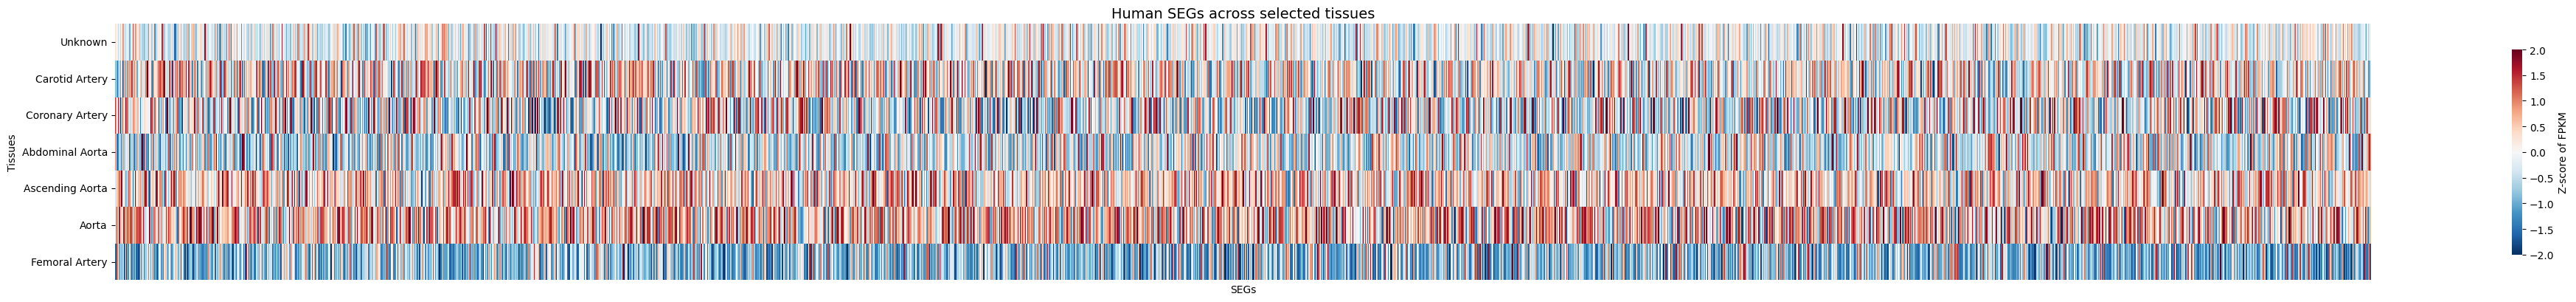

In [ ]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
from scipy import sparse
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# scCompass Figure 3e 风格复刻版（只画 SEGs）
# single-cell raw counts -> pseudo-bulk by tissue -> FPKM -> heatmap of SEGs
# =========================================================

# -------------------------------
# 配置区：按你的文件修改
# -------------------------------
PATH_H5AD = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/output_0121/Big-atlas-withlevel3-human_withUMAP2.h5ad"
PATH_SEG = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_results/human_SEG_result.csv"
PATH_GENE_LENGTH = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/SEGs/FPKM/human_gene_length.tsv"

SPECIES = "human"   # human / mouse
TISSUE_COL = "tissue"
SEG_COL = "gene"

# 是否指定论文那10个器官对应的 tissue 名称
# 不指定就按细胞数最多前10个 tissue
TARGET_TISSUES = None
TOP_N_TISSUES = 10

# 如果 h5ad 里 raw counts 在 layers 里，可以填，比如 "counts"
COUNTS_LAYER = None

# 输出目录
OUTDIR = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_heatmap_onlySEG"
os.makedirs(OUTDIR, exist_ok=True)

# 画图参数
CMAP = "RdBu_r"
VMIN = -2
VMAX = 2
DPI = 300


# -------------------------------
# 工具函数
# -------------------------------
def read_gene_list(file_path, col_name=None, sep=","):
    ext = os.path.splitext(file_path)[1].lower()

    if ext == ".csv":
        df = pd.read_csv(file_path, sep=sep)
    elif ext in [".tsv", ".txt"]:
        df = pd.read_csv(file_path, sep=sep)
    elif ext in [".xlsx", ".xls"]:
        df = pd.read_excel(file_path)
    else:
        raise ValueError(f"不支持的文件格式: {file_path}")

    if col_name is None:
        genes = df.iloc[:, 0].astype(str).str.strip().tolist()
    else:
        genes = df[col_name].astype(str).str.strip().tolist()

    genes = [g for g in genes if g and g.lower() != "nan"]
    return list(pd.Index(genes).unique())


def normalize_gene_case(gene_list, species):
    if species.lower() == "human":
        return [g.upper() for g in gene_list]
    else:
        return [g.capitalize() for g in gene_list]


def prepare_counts_adata(adata, counts_layer=None):
    """
    若指定了 counts_layer，则把该层作为 X 使用。
    否则直接使用 adata.X。
    """
    if counts_layer is None:
        return adata.copy()

    if counts_layer not in adata.layers:
        raise KeyError(f"adata.layers 中找不到: {counts_layer}")

    ad = adata.copy()
    ad.X = ad.layers[counts_layer].copy()
    return ad


def check_raw_counts(adata):
    X = adata.X
    if sparse.issparse(X):
        vals = X.data
    else:
        vals = np.asarray(X).ravel()

    if vals.size == 0:
        raise ValueError("adata.X 为空。")

    frac_nonint = np.mean(np.abs(vals - np.round(vals)) > 1e-8)
    if frac_nonint > 0.01:
        print("WARNING: adata.X 含较多非整数值，可能不是 raw counts。")
        print("WARNING: 若不是 raw counts，则不严格符合论文 pseudo-bulk -> FPKM 流程。")


def load_gene_length_table(path_gene_length):
    gene_len_df = pd.read_csv(path_gene_length, sep="\t")
    if not {"gene", "length"}.issubset(gene_len_df.columns):
        raise ValueError("gene_length 文件必须包含两列: gene, length")

    gene_len_df = gene_len_df.dropna(subset=["gene", "length"]).copy()
    gene_len_df["gene"] = gene_len_df["gene"].astype(str)
    gene_len_df["length"] = gene_len_df["length"].astype(float)
    gene_len_df = gene_len_df.drop_duplicates(subset=["gene"])
    return dict(zip(gene_len_df["gene"], gene_len_df["length"]))


def choose_tissues(adata, tissue_col, target_tissues=None, top_n=10):
    tissue_counts = adata.obs[tissue_col].astype(str).value_counts()

    if target_tissues is not None:
        available = set(tissue_counts.index)
        final_tissues = [t for t in target_tissues if t in available]
        missing = [t for t in target_tissues if t not in available]
        print("指定 tissues 中实际匹配到:", final_tissues)
        if missing:
            print("以下 tissues 不存在:", missing)
        if len(final_tissues) == 0:
            raise ValueError("TARGET_TISSUES 一个都没匹配到。")
        return final_tissues, tissue_counts

    final_tissues = tissue_counts.head(top_n).index.tolist()
    return final_tissues, tissue_counts


def build_pseudobulk_sum(adata, tissue_col, tissues_to_use, genes_to_use):
    """
    按 tissue 求和构建 pseudo-bulk
    行=tissue，列=gene
    """
    adata_sub = adata[adata.obs[tissue_col].astype(str).isin(tissues_to_use), genes_to_use].copy()

    pseudo_bulk = []
    tissue_order = []

    for t in tissues_to_use:
        sub = adata_sub[adata_sub.obs[tissue_col].astype(str) == t]

        if sub.n_obs == 0:
            continue

        if sparse.issparse(sub.X):
            summed = np.asarray(sub.X.sum(axis=0)).ravel()
        else:
            summed = np.asarray(sub.X.sum(axis=0)).ravel()

        pseudo_bulk.append(summed)
        tissue_order.append(t)

    pseudobulk_df = pd.DataFrame(
        np.vstack(pseudo_bulk),
        index=tissue_order,
        columns=adata_sub.var_names.astype(str)
    )
    return pseudobulk_df


def make_fpkm(count_df, gene_len_dict):
    lengths = np.array([gene_len_dict.get(g, np.nan) for g in count_df.columns], dtype=float)
    valid = ~np.isnan(lengths)

    count_df = count_df.loc[:, valid].copy()
    lengths = lengths[valid]

    counts = count_df.values.astype(float)
    libsize = counts.sum(axis=1, keepdims=True)
    libsize[libsize == 0] = np.nan

    fpkm = counts / (lengths / 1000.0) / (libsize / 1e6)

    fpkm_df = pd.DataFrame(
        fpkm,
        index=count_df.index,
        columns=count_df.columns
    )
    return fpkm_df


def zscore_by_gene(df):
    mean = df.mean(axis=0)
    std = df.std(axis=0, ddof=1)
    std = std.replace(0, np.nan)

    z_df = (df - mean) / std
    return z_df.fillna(0)


# -------------------------------
# 0. 检查文件
# -------------------------------
for p in [PATH_H5AD, PATH_SEG, PATH_GENE_LENGTH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"文件不存在: {p}")

# -------------------------------
# 1. 读取 h5ad
# -------------------------------
print("读取 h5ad...")
adata = sc.read_h5ad(PATH_H5AD)

if TISSUE_COL not in adata.obs.columns:
    raise KeyError(f"adata.obs 中找不到列: {TISSUE_COL}")

if COUNTS_LAYER is not None:
    print(f"使用 counts layer: {COUNTS_LAYER}")
adata = prepare_counts_adata(adata, COUNTS_LAYER)

print("细胞数:", adata.n_obs)
print("基因数:", adata.n_vars)
check_raw_counts(adata)

# -------------------------------
# 2. 读取 SEG
# -------------------------------
print("读取 SEG...")
seg_list = read_gene_list(PATH_SEG, col_name=SEG_COL, sep=",")
seg_list = normalize_gene_case(seg_list, SPECIES)

var_names_set = set(adata.var_names.astype(str))
seg_found = [g for g in seg_list if g in var_names_set]

print("匹配到 SEG:", len(seg_found))

if len(seg_found) == 0:
    raise ValueError("没有在 h5ad 中匹配到任何 SEG 基因。")

genes_to_plot = seg_found

# -------------------------------
# 3. 选择 tissues
# -------------------------------
if TARGET_TISSUES is None:
    print(f"选择细胞数最多的前 {TOP_N_TISSUES} 个 tissues...")
else:
    print("使用指定 tissues...")

final_tissues, tissue_counts = choose_tissues(
    adata=adata,
    tissue_col=TISSUE_COL,
    target_tissues=TARGET_TISSUES,
    top_n=TOP_N_TISSUES
)
print(final_tissues)

# -------------------------------
# 4. 构建 pseudo-bulk counts
# -------------------------------
print("构建 pseudo-bulk(sum counts)...")
pseudobulk_df = build_pseudobulk_sum(
    adata=adata,
    tissue_col=TISSUE_COL,
    tissues_to_use=final_tissues,
    genes_to_use=genes_to_plot
)
print("pseudo-bulk 维度:", pseudobulk_df.shape)

# -------------------------------
# 5. 读取 gene length 并转 FPKM
# -------------------------------
print("读取 gene length...")
gene_len_dict = load_gene_length_table(PATH_GENE_LENGTH)

print("计算 FPKM...")
fpkm_df = make_fpkm(pseudobulk_df, gene_len_dict)

# 保持 SEG 原始顺序
genes_after_fpkm = [g for g in genes_to_plot if g in fpkm_df.columns]
fpkm_df = fpkm_df.loc[final_tissues, genes_after_fpkm]

print("FPKM 矩阵维度:", fpkm_df.shape)

# -------------------------------
# 6. Z-score
# -------------------------------
print("按基因做 Z-score...")
z_df = zscore_by_gene(fpkm_df)

# -------------------------------
# 7. 画热图
# -------------------------------
print("绘制热图...")
n_genes = z_df.shape[1]
n_tissues = z_df.shape[0]

fig_width = min(40, max(10, n_genes * 0.18))
fig_height = min(12, max(4, n_tissues * 0.6))

plt.figure(figsize=(fig_width, fig_height))
ax = sns.heatmap(
    z_df,
    cmap=CMAP,
    center=0,
    vmin=VMIN,
    vmax=VMAX,
    cbar_kws={"label": "Z-score of FPKM", "shrink": 0.8},
    xticklabels=False if n_genes > 80 else True,
    yticklabels=True
)

ax.set_title(
    f"{SPECIES.capitalize()} SEGs across selected tissues",
    fontsize=14
)
ax.set_xlabel("SEGs")
ax.set_ylabel("Tissues")

plt.tight_layout()

# -------------------------------
# 8. 输出
# -------------------------------
out_png = os.path.join(OUTDIR, f"{SPECIES.lower()}_SEG_pseudobulk_FPKM_heatmap.png")
out_pdf = os.path.join(OUTDIR, f"{SPECIES.lower()}_SEG_pseudobulk_FPKM_heatmap.pdf")
out_fpkm = os.path.join(OUTDIR, f"{SPECIES.lower()}_SEG_pseudobulk_FPKM_matrix.csv")
out_z = os.path.join(OUTDIR, f"{SPECIES.lower()}_SEG_pseudobulk_FPKM_zscore_matrix.csv")
out_tissues = os.path.join(OUTDIR, f"{SPECIES.lower()}_tissues_used.csv")

plt.savefig(out_png, dpi=DPI, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")

fpkm_df.to_csv(out_fpkm)
z_df.to_csv(out_z)
pd.DataFrame({
    "tissue": final_tissues,
    "cell_count": [tissue_counts[t] for t in final_tissues]
}).to_csv(out_tissues, index=False)

print("输出完成:")
print(out_png)
print(out_pdf)
print(out_fpkm)
print(out_z)
print(out_tissues)

plt.show()

读取 h5ad...


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


细胞数: 562562
基因数: 57678
读取 SEG...
读取 HKG...


/tmp/ipykernel_3512147/2195269687.py:69: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  return list(pd.unique(genes))
/tmp/ipykernel_3512147/2195269687.py:227: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  hkg_list = normalize_gene_case(list(pd.unique(hkg_list)), SPECIES)


匹配到 SEG: 3235
匹配到 HKG: 3149
选择细胞数最多的前 10 个 tissues...
['Abdominal Aorta', 'Aorta', 'Aorta and Carotid Artery', 'Ascending Aorta, Brachiocephalic Artery and Thoracic Aorta', 'Aortic root and Ascending Aorta', 'Carotid Artery', 'Aorta and Brachiocephalic Artery', 'Adventitia']
构建 pseudo-bulk(sum counts)...


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


pseudo-bulk 维度: (8, 6384)
读取 gene length...
计算 FPKM...
FPKM 矩阵维度: (8, 9642)
按基因做 Z-score...
绘制热图...
输出完成:
/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_heatmap_mouse/mouse_SEG_HKG_pseudobulk_FPKM_heatmap.png
/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_heatmap_mouse/mouse_SEG_HKG_pseudobulk_FPKM_heatmap.pdf
/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_heatmap_mouse/mouse_SEG_HKG_pseudobulk_FPKM_matrix.csv
/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_heatmap_mouse/mouse_SEG_HKG_pseudobulk_FPKM_zscore_matrix.csv
/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_heatmap_mouse/mouse_top_tissues_used.csv


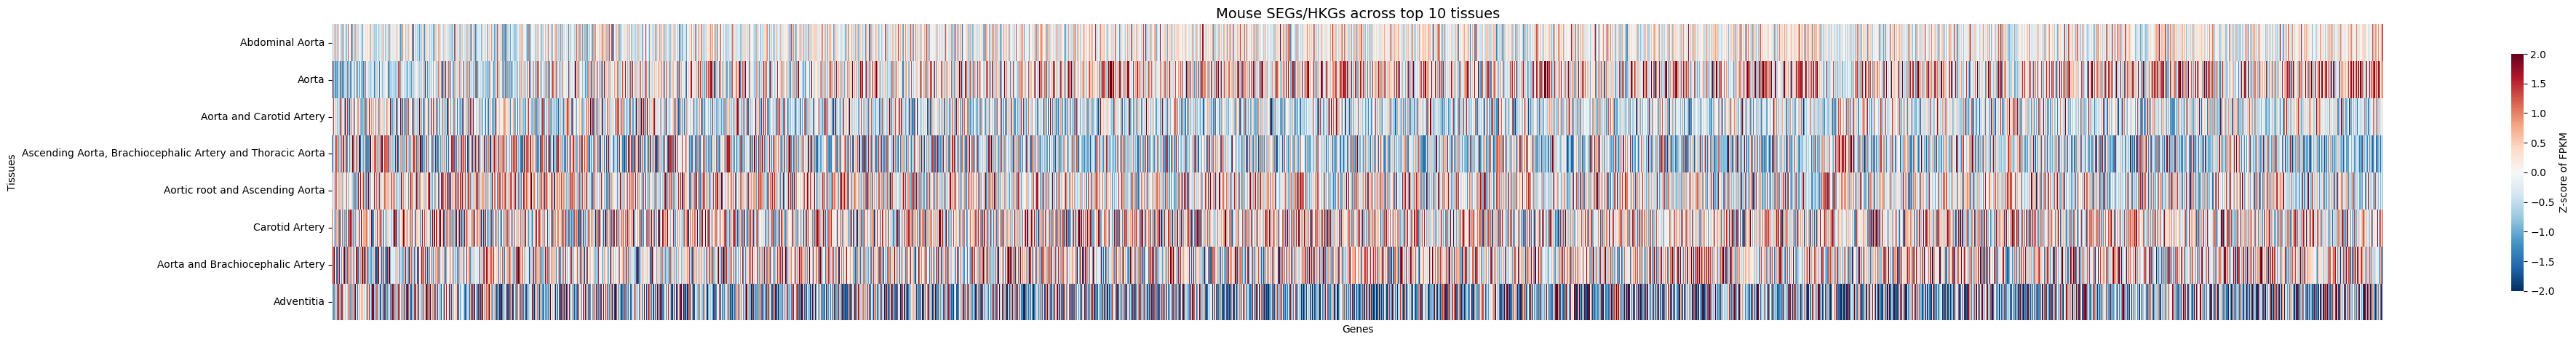

In [ ]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
from scipy import sparse
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# scCompass Figure 3e / S4 风格复刻版
# 论文方法：
# single-cell raw counts
# -> pseudo-bulk by organ/tissue
# -> FPKM
# -> heatmap of SEGs and HKGs across top 10 organs
# =========================================================

# -------------------------------
# 配置区：按你的文件修改
# -------------------------------
PATH_H5AD = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/output_0121/Big-atlas-withlevel3-mouse_withUMAP2.h5ad"
PATH_SEG = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_results/mouse_SEG_result.csv"
PATH_HKG = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/SEGs/Housekeeping_GenesMouse.csv"
PATH_GENE_LENGTH = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/SEGs/FPKM/mouse_gene_length.tsv"

SPECIES = "mouse"   # human / mouse
TISSUE_COL = "tissue"
SEG_COL = "gene"

# HKG 文件设置
HKG_SEP = ";"
HKG_COL = None   # None = 自动猜测

# top 10 tissues：论文用于热图评估的是 top 10 organs
TOP_N_TISSUES = 10

# 输出目录
OUTDIR = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_heatmap_mouse"
os.makedirs(OUTDIR, exist_ok=True)

# 画图参数
CMAP = "RdBu_r"
VMIN = -2
VMAX = 2
DPI = 300


# -------------------------------
# 工具函数
# -------------------------------
def read_gene_list(file_path, col_name=None, sep=","):
    ext = os.path.splitext(file_path)[1].lower()

    if ext == ".csv":
        df = pd.read_csv(file_path, sep=sep)
    elif ext in [".tsv", ".txt"]:
        df = pd.read_csv(file_path, sep=sep)
    elif ext in [".xlsx", ".xls"]:
        df = pd.read_excel(file_path)
    else:
        raise ValueError(f"不支持的文件格式: {file_path}")

    if col_name is None:
        genes = df.iloc[:, 0].astype(str).str.strip().tolist()
    else:
        genes = df[col_name].astype(str).str.strip().tolist()

    genes = [g for g in genes if g and g.lower() != "nan"]
    return list(pd.unique(genes))


def auto_detect_hkg_col(df):
    candidates = ["gene", "genes", "symbol", "gene_symbol", "Gene", "GeneSymbol"]
    for c in candidates:
        if c in df.columns:
            return c
    if df.shape[1] >= 2:
        return df.columns[1]
    return df.columns[0]


def normalize_gene_case(gene_list, species):
    if species.lower() == "human":
        return [g.upper() for g in gene_list]
    else:
        return [g.capitalize() for g in gene_list]


def check_raw_counts(adata):
    """
    论文流程要求 count-based pseudo-bulk -> FPKM。
    这里只做一个简单检查，不能百分百证明，但能排除明显不是 counts 的情况。
    """
    X = adata.X
    if sparse.issparse(X):
        vals = X.data
    else:
        vals = np.asarray(X).ravel()

    if vals.size == 0:
        raise ValueError("adata.X 为空。")

    frac_nonint = np.mean(np.abs(vals - np.round(vals)) > 1e-8)
    if frac_nonint > 0.01:
        print("WARNING: adata.X 含较多非整数值，可能不是 raw counts。")
        print("WARNING: 若不是 raw counts，则不符合论文热图流程。")


def load_gene_length_table(path_gene_length):
    gene_len_df = pd.read_csv(path_gene_length, sep="\t")
    if not {"gene", "length"}.issubset(gene_len_df.columns):
        raise ValueError("gene_length 文件必须包含两列: gene, length")

    gene_len_df = gene_len_df.dropna(subset=["gene", "length"]).copy()
    gene_len_df["gene"] = gene_len_df["gene"].astype(str)
    gene_len_df["length"] = gene_len_df["length"].astype(float)
    gene_len_df = gene_len_df.drop_duplicates(subset=["gene"])
    return dict(zip(gene_len_df["gene"], gene_len_df["length"]))


def choose_top_tissues(adata, tissue_col, top_n=10):
    tissue_counts = adata.obs[tissue_col].astype(str).value_counts()
    final_tissues = tissue_counts.head(top_n).index.tolist()
    return final_tissues, tissue_counts


def build_pseudobulk_sum(adata, tissue_col, tissues_to_use, genes_to_use):
    """
    按 tissue 求和构建 pseudo-bulk
    行=tissue，列=gene
    """
    adata_sub = adata[adata.obs[tissue_col].astype(str).isin(tissues_to_use), genes_to_use].copy()

    pseudo_bulk = []
    tissue_order = []

    for t in tissues_to_use:
        sub = adata_sub[adata_sub.obs[tissue_col].astype(str) == t]

        if sub.n_obs == 0:
            continue

        if sparse.issparse(sub.X):
            summed = np.asarray(sub.X.sum(axis=0)).ravel()
        else:
            summed = np.asarray(sub.X.sum(axis=0)).ravel()

        pseudo_bulk.append(summed)
        tissue_order.append(t)

    pseudobulk_df = pd.DataFrame(
        np.vstack(pseudo_bulk),
        index=tissue_order,
        columns=adata_sub.var_names.astype(str)
    )
    return pseudobulk_df


def make_fpkm(count_df, gene_len_dict):
    lengths = np.array([gene_len_dict.get(g, np.nan) for g in count_df.columns], dtype=float)
    valid = ~np.isnan(lengths)

    count_df = count_df.loc[:, valid].copy()
    lengths = lengths[valid]

    counts = count_df.values.astype(float)
    libsize = counts.sum(axis=1, keepdims=True)
    libsize[libsize == 0] = np.nan

    fpkm = counts / (lengths / 1000.0) / (libsize / 1e6)

    fpkm_df = pd.DataFrame(
        fpkm,
        index=count_df.index,
        columns=count_df.columns
    )
    return fpkm_df


def zscore_by_gene(df):
    """
    每列一个基因，按列做 Z-score
    论文未公开热图内部标准化脚本，这里采用最常见的列标准化方式
    """
    mean = df.mean(axis=0)
    std = df.std(axis=0, ddof=1)
    std = std.replace(0, np.nan)

    z_df = (df - mean) / std
    return z_df.fillna(0)


# -------------------------------
# 1. 读取 h5ad
# -------------------------------
print("读取 h5ad...")
adata = sc.read(PATH_H5AD)

if TISSUE_COL not in adata.obs.columns:
    raise KeyError(f"adata.obs 中找不到列: {TISSUE_COL}")

print("细胞数:", adata.n_obs)
print("基因数:", adata.n_vars)
check_raw_counts(adata)

# -------------------------------
# 2. 读取 SEG / HKG
# -------------------------------
print("读取 SEG...")
seg_list = read_gene_list(PATH_SEG, col_name=SEG_COL, sep=",")
seg_list = normalize_gene_case(seg_list, SPECIES)

print("读取 HKG...")
ext = os.path.splitext(PATH_HKG)[1].lower()
if ext == ".csv":
    hkg_df = pd.read_csv(PATH_HKG, sep=HKG_SEP)
elif ext in [".tsv", ".txt"]:
    hkg_df = pd.read_csv(PATH_HKG, sep=HKG_SEP)
elif ext in [".xlsx", ".xls"]:
    hkg_df = pd.read_excel(PATH_HKG)
else:
    raise ValueError(f"不支持的 HKG 文件格式: {PATH_HKG}")

hkg_col = auto_detect_hkg_col(hkg_df) if HKG_COL is None else HKG_COL
hkg_list = hkg_df[hkg_col].astype(str).str.strip().tolist()
hkg_list = [g for g in hkg_list if g and g.lower() != "nan"]
hkg_list = normalize_gene_case(list(pd.unique(hkg_list)), SPECIES)

# 保持顺序合并：先 SEG 后 HKG
all_genes = seg_list + hkg_list
all_genes = list(dict.fromkeys(all_genes))

var_names_set = set(adata.var_names.astype(str))
genes_found = [g for g in all_genes if g in var_names_set]
seg_found = [g for g in seg_list if g in genes_found]
hkg_found = [g for g in hkg_list if g in genes_found]

print("匹配到 SEG:", len(seg_found))
print("匹配到 HKG:", len(hkg_found))

if len(seg_found) == 0:
    raise ValueError("没有在 h5ad 中匹配到任何 SEG 基因。")

genes_to_plot = seg_found + hkg_found

# -------------------------------
# 3. 选 top 10 tissues
# -------------------------------
print(f"选择细胞数最多的前 {TOP_N_TISSUES} 个 tissues...")
final_tissues, tissue_counts = choose_top_tissues(adata, TISSUE_COL, TOP_N_TISSUES)
print(final_tissues)

# -------------------------------
# 4. 构建 pseudo-bulk counts
# -------------------------------
print("构建 pseudo-bulk(sum counts)...")
pseudobulk_df = build_pseudobulk_sum(
    adata=adata,
    tissue_col=TISSUE_COL,
    tissues_to_use=final_tissues,
    genes_to_use=genes_to_plot
)
print("pseudo-bulk 维度:", pseudobulk_df.shape)

# -------------------------------
# 5. 读取 gene length 并转 FPKM
# -------------------------------
print("读取 gene length...")
gene_len_dict = load_gene_length_table(PATH_GENE_LENGTH)

print("计算 FPKM...")
fpkm_df = make_fpkm(pseudobulk_df, gene_len_dict)

# 重新按原始基因顺序排列
genes_after_fpkm = [g for g in genes_to_plot if g in fpkm_df.columns]
fpkm_df = fpkm_df.loc[final_tissues, genes_after_fpkm]

print("FPKM 矩阵维度:", fpkm_df.shape)

# -------------------------------
# 6. Z-score
# -------------------------------
print("按基因做 Z-score...")
z_df = zscore_by_gene(fpkm_df)

# -------------------------------
# 7. 画热图
# -------------------------------
print("绘制热图...")
n_genes = z_df.shape[1]
n_tissues = z_df.shape[0]

fig_width = min(40, max(10, n_genes * 0.18))
fig_height = min(12, max(4, n_tissues * 0.6))

plt.figure(figsize=(fig_width, fig_height))
ax = sns.heatmap(
    z_df,
    cmap=CMAP,
    center=0,
    vmin=VMIN,
    vmax=VMAX,
    cbar_kws={"label": "Z-score of FPKM", "shrink": 0.8},
    xticklabels=False if n_genes > 80 else True,
    yticklabels=True
)

ax.set_title(
    f"{SPECIES.capitalize()} SEGs/HKGs across top {TOP_N_TISSUES} tissues",
    fontsize=14
)
ax.set_xlabel("Genes")
ax.set_ylabel("Tissues")

plt.tight_layout()

# -------------------------------
# 8. 输出
# -------------------------------
out_png = os.path.join(OUTDIR, f"{SPECIES.lower()}_SEG_HKG_pseudobulk_FPKM_heatmap.png")
out_pdf = os.path.join(OUTDIR, f"{SPECIES.lower()}_SEG_HKG_pseudobulk_FPKM_heatmap.pdf")
out_fpkm = os.path.join(OUTDIR, f"{SPECIES.lower()}_SEG_HKG_pseudobulk_FPKM_matrix.csv")
out_z = os.path.join(OUTDIR, f"{SPECIES.lower()}_SEG_HKG_pseudobulk_FPKM_zscore_matrix.csv")
out_tissues = os.path.join(OUTDIR, f"{SPECIES.lower()}_top_tissues_used.csv")

plt.savefig(out_png, dpi=DPI, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")

fpkm_df.to_csv(out_fpkm)
z_df.to_csv(out_z)
pd.DataFrame({
    "tissue": final_tissues,
    "cell_count": [tissue_counts[t] for t in final_tissues]
}).to_csv(out_tissues, index=False)

print("输出完成:")
print(out_png)
print(out_pdf)
print(out_fpkm)
print(out_z)
print(out_tissues)

plt.show()

读取 h5ad...
细胞数: 562562
基因数: 57678
读取 SEG...
匹配到 SEG: 3235
选择细胞数最多的前 10 个 tissues...
['Abdominal Aorta', 'Aorta', 'Aorta and Carotid Artery', 'Ascending Aorta, Brachiocephalic Artery and Thoracic Aorta', 'Aortic root and Ascending Aorta', 'Carotid Artery', 'Aorta and Brachiocephalic Artery', 'Adventitia']
构建 pseudo-bulk(sum counts)...
pseudo-bulk 维度: (8, 3235)
读取 gene length...
计算 FPKM...
FPKM 矩阵维度: (8, 3235)
按基因做 Z-score...
绘制热图...
输出完成:
/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_heatmap_mouse_onlySEG/mouse_SEG_pseudobulk_FPKM_heatmap.png
/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_heatmap_mouse_onlySEG/mouse_SEG_pseudobulk_FPKM_heatmap.pdf
/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_heatmap_mouse_onlySEG/mouse_SEG_pseudobulk_FPKM_matrix.csv
/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_heatmap_mouse_onlySEG/mouse_SEG_pseudobulk_FPKM_zscore_matrix.csv
/home/lixiangyu/zr/Annota

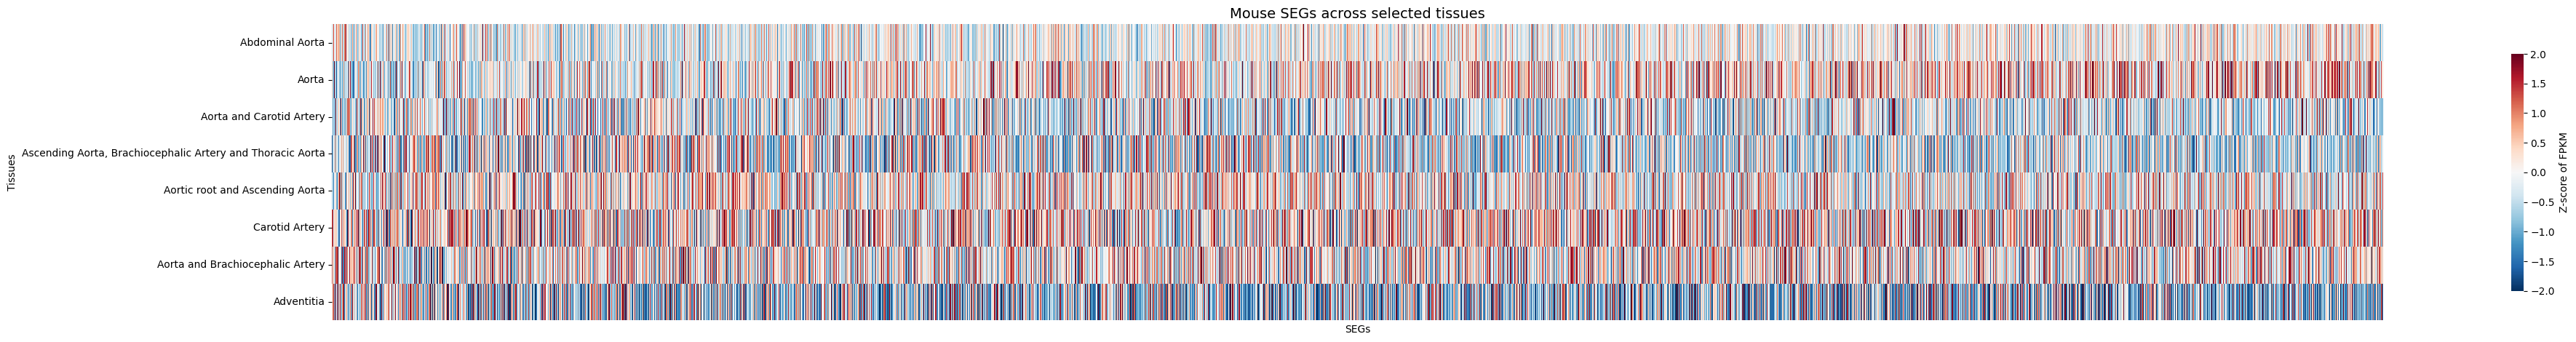

In [6]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
from scipy import sparse
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# scCompass Figure 3e / S4 风格复刻版（mouse，只画 SEGs）
# single-cell raw counts -> pseudo-bulk by tissue -> FPKM -> heatmap of SEGs
# =========================================================

# -------------------------------
# 配置区：按你的文件修改
# -------------------------------
PATH_H5AD = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/output_0121/Big-atlas-withlevel3-mouse_withUMAP2.h5ad"
PATH_SEG = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_results/mouse_SEG_result.csv"
PATH_GENE_LENGTH = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/SEGs/FPKM/mouse_gene_length.tsv"

SPECIES = "mouse"
TISSUE_COL = "tissue"
SEG_COL = "gene"

# 如果你已经知道论文那10个 organs 在你数据里对应的名字，可以手动填
# 不填就自动取细胞数最多的前10个 tissue
TARGET_TISSUES = None
TOP_N_TISSUES = 10

# 如果 raw counts 在 layer 里，比如 "counts"，就填；否则保持 None
COUNTS_LAYER = None

# 输出目录
OUTDIR = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_heatmap_mouse_onlySEG"
os.makedirs(OUTDIR, exist_ok=True)

# 画图参数
CMAP = "RdBu_r"
VMIN = -2
VMAX = 2
DPI = 300


# -------------------------------
# 工具函数
# -------------------------------
def read_gene_list(file_path, col_name=None, sep=","):
    ext = os.path.splitext(file_path)[1].lower()

    if ext == ".csv":
        df = pd.read_csv(file_path, sep=sep)
    elif ext in [".tsv", ".txt"]:
        df = pd.read_csv(file_path, sep=sep)
    elif ext in [".xlsx", ".xls"]:
        df = pd.read_excel(file_path)
    else:
        raise ValueError(f"不支持的文件格式: {file_path}")

    if col_name is None:
        genes = df.iloc[:, 0].astype(str).str.strip().tolist()
    else:
        genes = df[col_name].astype(str).str.strip().tolist()

    genes = [g for g in genes if g and g.lower() != "nan"]
    return list(pd.Index(genes).unique())


def normalize_gene_case(gene_list, species):
    if species.lower() == "human":
        return [g.upper() for g in gene_list]
    else:
        return [g.capitalize() for g in gene_list]


def prepare_counts_adata(adata, counts_layer=None):
    """
    若指定了 counts_layer，则把该层作为 X 使用；
    否则直接使用 adata.X。
    """
    if counts_layer is None:
        return adata.copy()

    if counts_layer not in adata.layers:
        raise KeyError(f"adata.layers 中找不到: {counts_layer}")

    ad = adata.copy()
    ad.X = ad.layers[counts_layer].copy()
    return ad


def check_raw_counts(adata):
    """
    论文热图流程要求 count-based pseudo-bulk -> FPKM。
    这里只做简单检查。
    """
    X = adata.X
    if sparse.issparse(X):
        vals = X.data
    else:
        vals = np.asarray(X).ravel()

    if vals.size == 0:
        raise ValueError("adata.X 为空。")

    frac_nonint = np.mean(np.abs(vals - np.round(vals)) > 1e-8)
    if frac_nonint > 0.01:
        print("WARNING: adata.X 含较多非整数值，可能不是 raw counts。")
        print("WARNING: 若不是 raw counts，则不严格符合论文 pseudo-bulk -> FPKM 流程。")


def load_gene_length_table(path_gene_length):
    gene_len_df = pd.read_csv(path_gene_length, sep="\t")
    if not {"gene", "length"}.issubset(gene_len_df.columns):
        raise ValueError("gene_length 文件必须包含两列: gene, length")

    gene_len_df = gene_len_df.dropna(subset=["gene", "length"]).copy()
    gene_len_df["gene"] = gene_len_df["gene"].astype(str)
    gene_len_df["length"] = gene_len_df["length"].astype(float)
    gene_len_df = gene_len_df.drop_duplicates(subset=["gene"])
    return dict(zip(gene_len_df["gene"], gene_len_df["length"]))


def choose_tissues(adata, tissue_col, target_tissues=None, top_n=10):
    tissue_counts = adata.obs[tissue_col].astype(str).value_counts()

    if target_tissues is not None:
        available = set(tissue_counts.index)
        final_tissues = [t for t in target_tissues if t in available]
        missing = [t for t in target_tissues if t not in available]
        print("指定 tissues 中实际匹配到:", final_tissues)
        if missing:
            print("以下 tissues 不存在:", missing)
        if len(final_tissues) == 0:
            raise ValueError("TARGET_TISSUES 一个都没匹配到。")
        return final_tissues, tissue_counts

    final_tissues = tissue_counts.head(top_n).index.tolist()
    return final_tissues, tissue_counts


def build_pseudobulk_sum(adata, tissue_col, tissues_to_use, genes_to_use):
    """
    按 tissue 求和构建 pseudo-bulk
    行=tissue，列=gene
    """
    adata_sub = adata[adata.obs[tissue_col].astype(str).isin(tissues_to_use), genes_to_use].copy()

    pseudo_bulk = []
    tissue_order = []

    for t in tissues_to_use:
        sub = adata_sub[adata_sub.obs[tissue_col].astype(str) == t]

        if sub.n_obs == 0:
            continue

        if sparse.issparse(sub.X):
            summed = np.asarray(sub.X.sum(axis=0)).ravel()
        else:
            summed = np.asarray(sub.X.sum(axis=0)).ravel()

        pseudo_bulk.append(summed)
        tissue_order.append(t)

    pseudobulk_df = pd.DataFrame(
        np.vstack(pseudo_bulk),
        index=tissue_order,
        columns=adata_sub.var_names.astype(str)
    )
    return pseudobulk_df


def make_fpkm(count_df, gene_len_dict):
    lengths = np.array([gene_len_dict.get(g, np.nan) for g in count_df.columns], dtype=float)
    valid = ~np.isnan(lengths)

    count_df = count_df.loc[:, valid].copy()
    lengths = lengths[valid]

    counts = count_df.values.astype(float)
    libsize = counts.sum(axis=1, keepdims=True)
    libsize[libsize == 0] = np.nan

    fpkm = counts / (lengths / 1000.0) / (libsize / 1e6)

    fpkm_df = pd.DataFrame(
        fpkm,
        index=count_df.index,
        columns=count_df.columns
    )
    return fpkm_df


def zscore_by_gene(df):
    mean = df.mean(axis=0)
    std = df.std(axis=0, ddof=1)
    std = std.replace(0, np.nan)

    z_df = (df - mean) / std
    return z_df.fillna(0)


# -------------------------------
# 0. 检查文件
# -------------------------------
for p in [PATH_H5AD, PATH_SEG, PATH_GENE_LENGTH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"文件不存在: {p}")

# -------------------------------
# 1. 读取 h5ad
# -------------------------------
print("读取 h5ad...")
adata = sc.read_h5ad(PATH_H5AD)

if TISSUE_COL not in adata.obs.columns:
    raise KeyError(f"adata.obs 中找不到列: {TISSUE_COL}")

if COUNTS_LAYER is not None:
    print(f"使用 counts layer: {COUNTS_LAYER}")
adata = prepare_counts_adata(adata, COUNTS_LAYER)

print("细胞数:", adata.n_obs)
print("基因数:", adata.n_vars)
check_raw_counts(adata)

# -------------------------------
# 2. 读取 SEG
# -------------------------------
print("读取 SEG...")
seg_list = read_gene_list(PATH_SEG, col_name=SEG_COL, sep=",")
seg_list = normalize_gene_case(seg_list, SPECIES)

var_names_set = set(adata.var_names.astype(str))
seg_found = [g for g in seg_list if g in var_names_set]

print("匹配到 SEG:", len(seg_found))

if len(seg_found) == 0:
    raise ValueError("没有在 h5ad 中匹配到任何 SEG 基因。")

genes_to_plot = seg_found

# -------------------------------
# 3. 选择 tissues
# -------------------------------
if TARGET_TISSUES is None:
    print(f"选择细胞数最多的前 {TOP_N_TISSUES} 个 tissues...")
else:
    print("使用指定 tissues...")

final_tissues, tissue_counts = choose_tissues(
    adata=adata,
    tissue_col=TISSUE_COL,
    target_tissues=TARGET_TISSUES,
    top_n=TOP_N_TISSUES
)
print(final_tissues)

# -------------------------------
# 4. 构建 pseudo-bulk counts
# -------------------------------
print("构建 pseudo-bulk(sum counts)...")
pseudobulk_df = build_pseudobulk_sum(
    adata=adata,
    tissue_col=TISSUE_COL,
    tissues_to_use=final_tissues,
    genes_to_use=genes_to_plot
)
print("pseudo-bulk 维度:", pseudobulk_df.shape)

# -------------------------------
# 5. gene length -> FPKM
# -------------------------------
print("读取 gene length...")
gene_len_dict = load_gene_length_table(PATH_GENE_LENGTH)

print("计算 FPKM...")
fpkm_df = make_fpkm(pseudobulk_df, gene_len_dict)

# 保持 SEG 原始顺序
genes_after_fpkm = [g for g in genes_to_plot if g in fpkm_df.columns]
fpkm_df = fpkm_df.loc[final_tissues, genes_after_fpkm]

print("FPKM 矩阵维度:", fpkm_df.shape)

# -------------------------------
# 6. Z-score
# -------------------------------
print("按基因做 Z-score...")
z_df = zscore_by_gene(fpkm_df)

# -------------------------------
# 7. 画热图
# -------------------------------
print("绘制热图...")
n_genes = z_df.shape[1]
n_tissues = z_df.shape[0]

fig_width = min(40, max(10, n_genes * 0.18))
fig_height = min(12, max(4, n_tissues * 0.6))

plt.figure(figsize=(fig_width, fig_height))
ax = sns.heatmap(
    z_df,
    cmap=CMAP,
    center=0,
    vmin=VMIN,
    vmax=VMAX,
    cbar_kws={"label": "Z-score of FPKM", "shrink": 0.8},
    xticklabels=False if n_genes > 80 else True,
    yticklabels=True
)

ax.set_title(
    f"{SPECIES.capitalize()} SEGs across selected tissues",
    fontsize=14
)
ax.set_xlabel("SEGs")
ax.set_ylabel("Tissues")

plt.tight_layout()

# -------------------------------
# 8. 输出
# -------------------------------
out_png = os.path.join(OUTDIR, f"{SPECIES.lower()}_SEG_pseudobulk_FPKM_heatmap.png")
out_pdf = os.path.join(OUTDIR, f"{SPECIES.lower()}_SEG_pseudobulk_FPKM_heatmap.pdf")
out_fpkm = os.path.join(OUTDIR, f"{SPECIES.lower()}_SEG_pseudobulk_FPKM_matrix.csv")
out_z = os.path.join(OUTDIR, f"{SPECIES.lower()}_SEG_pseudobulk_FPKM_zscore_matrix.csv")
out_tissues = os.path.join(OUTDIR, f"{SPECIES.lower()}_tissues_used.csv")

plt.savefig(out_png, dpi=DPI, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")

fpkm_df.to_csv(out_fpkm)
z_df.to_csv(out_z)
pd.DataFrame({
    "tissue": final_tissues,
    "cell_count": [tissue_counts[t] for t in final_tissues]
}).to_csv(out_tissues, index=False)

print("输出完成:")
print(out_png)
print(out_pdf)
print(out_fpkm)
print(out_z)
print(out_tissues)

plt.show()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


SEG 总基因数（文件去重）: 2176
SEG 匹配基因数: 2176
HKG 匹配基因数: 2162
SEG vs HKG p-value = 8.33e-100


/tmp/ipykernel_1420964/1952156681.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Group", y="CV", data=plot_df, palette=["#E64398", "#00B4D8"])


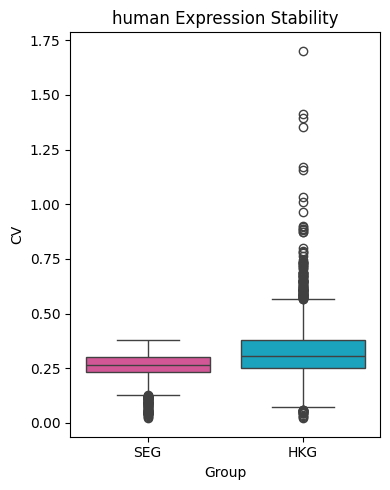

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ====================== 【配置】你只需要改这里 ======================
adata_path = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/output_0121/Big-atlas-withlevel3-human_withUMAP2.h5ad"
seg_path = "//home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_results/human_SEG_result.csv"
seg_col = "gene"
hkg_path = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/SEGs/Housekeeping_GenesHuman.csv"
tissue_col = "tissue"
species = "human"
# ==================================================================

# ---------------------- 1. 加载数据 ----------------------
adata = sc.read(adata_path)
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.log1p(adata)

# ---------------------- 2. 读取 SEG ----------------------
seg_df = pd.read_csv(seg_path, sep=",")
SEG_LIST = seg_df[seg_col].tolist()
SEG_LIST = list(set(SEG_LIST))  # 去重

# ---------------------- 3. 读取 HKG ----------------------
hkg_df = pd.read_csv(hkg_path, sep=";")
HKG_LIST = hkg_df.iloc[:, 1].tolist()
HKG_LIST = list(set(HKG_LIST))

# ---------------------- 4. 直接匹配，不转大写 ----------------------
all_genes = adata.var_names.tolist()
seg_found = [g for g in SEG_LIST if g in all_genes]
hkg_found = [g for g in HKG_LIST if g in all_genes]

print(f"SEG 总基因数（文件去重）: {len(SEG_LIST)}")
print(f"SEG 匹配基因数: {len(seg_found)}")
print(f"HKG 匹配基因数: {len(hkg_found)}")

# ---------------------- 5. 提取子集（不转大写！） ----------------------
keep_genes = list(set(seg_found + hkg_found))
adata_sub = adata[:, keep_genes]

# ---------------------- 6. 稀疏矩阵直接计算 pseudo-bulk，永不转密集 ----------------------
# 按组织分组，对每个基因求平均表达量（稀疏安全）
pseudo_bulk = []
labels = adata_sub.obs[tissue_col].values
for group in np.unique(labels):
    mask = labels == group
    # 稀疏矩阵直接求平均，不转密集
    mean_exp = adata_sub.X[mask].mean(axis=0).A1  # 只在最后拉成一维，不占内存
    pseudo_bulk.append(mean_exp)

pb_df = pd.DataFrame(pseudo_bulk, columns=adata_sub.var_names)

# ---------------------- 7. 计算 CV ----------------------
def calculate_cv(df):
    return df.std(axis=0) / df.mean(axis=0)

cv_series = calculate_cv(pb_df)
cv_seg = cv_series[seg_found]
cv_hkg = cv_series[hkg_found]

# ---------------------- 8. 统计检验 ----------------------
stat, pval = mannwhitneyu(cv_seg, cv_hkg, alternative='two-sided')
print(f"SEG vs HKG p-value = {pval:.2e}")

# ---------------------- 9. 画图 ----------------------
plot_df = pd.DataFrame({
    "CV": pd.concat([cv_seg, cv_hkg]),
    "Group": ["SEG"] * len(cv_seg) + ["HKG"] * len(cv_hkg)
})

plt.figure(figsize=(4, 5))
sns.boxplot(x="Group", y="CV", data=plot_df, palette=["#E64398", "#00B4D8"])
plt.title(f"{species} Expression Stability")
plt.ylabel("CV")
plt.tight_layout()
plt.savefig(f"{species}_SEG_vs_HKG.png", dpi=300)
plt.show()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


SEG 总基因数（文件去重）: 3277
SEG 匹配基因数: 3277
HKG 匹配基因数: 3184
SEG vs HKG p-value = 2.56e-62


/tmp/ipykernel_3512147/1248606924.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Group", y="CV", data=plot_df, palette=["#E64398", "#00B4D8"])


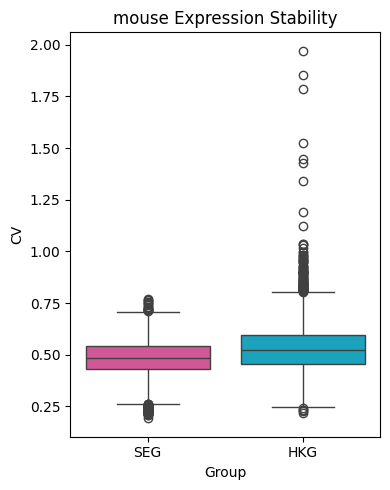

In [5]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ====================== 【配置】你只需要改这里 ======================
adata_path = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/output_0121/Big-atlas-withlevel3-mouse_withUMAP2.h5ad"
seg_path = "//home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/output/SEGs/SEGs_results/mouse_SEG_result.csv"
seg_col = "gene"
hkg_path = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/SEGs/Housekeeping_GenesMouse.csv"
tissue_col = "tissue"
species = "mouse"
# ==================================================================

# ---------------------- 1. 加载数据 ----------------------
adata = sc.read(adata_path)
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.log1p(adata)

# ---------------------- 2. 读取 SEG ----------------------
seg_df = pd.read_csv(seg_path, sep=",")
SEG_LIST = seg_df[seg_col].tolist()
SEG_LIST = list(set(SEG_LIST))  # 去重

# ---------------------- 3. 读取 HKG ----------------------
hkg_df = pd.read_csv(hkg_path, sep=";")
HKG_LIST = hkg_df.iloc[:, 1].tolist()
HKG_LIST = list(set(HKG_LIST))

# ---------------------- 4. 直接匹配，不转大写 ----------------------
all_genes = adata.var_names.tolist()
seg_found = [g for g in SEG_LIST if g in all_genes]
hkg_found = [g for g in HKG_LIST if g in all_genes]

print(f"SEG 总基因数（文件去重）: {len(SEG_LIST)}")
print(f"SEG 匹配基因数: {len(seg_found)}")
print(f"HKG 匹配基因数: {len(hkg_found)}")

# ---------------------- 5. 提取子集（不转大写！） ----------------------
keep_genes = list(set(seg_found + hkg_found))
adata_sub = adata[:, keep_genes]

# ---------------------- 6. 稀疏矩阵直接计算 pseudo-bulk，永不转密集 ----------------------
# 按组织分组，对每个基因求平均表达量（稀疏安全）
pseudo_bulk = []
labels = adata_sub.obs[tissue_col].values
for group in np.unique(labels):
    mask = labels == group
    # 稀疏矩阵直接求平均，不转密集
    mean_exp = adata_sub.X[mask].mean(axis=0).A1  # 只在最后拉成一维，不占内存
    pseudo_bulk.append(mean_exp)

pb_df = pd.DataFrame(pseudo_bulk, columns=adata_sub.var_names)

# ---------------------- 7. 计算 CV ----------------------
def calculate_cv(df):
    return df.std(axis=0) / df.mean(axis=0)

cv_series = calculate_cv(pb_df)
cv_seg = cv_series[seg_found]
cv_hkg = cv_series[hkg_found]

# ---------------------- 8. 统计检验 ----------------------
stat, pval = mannwhitneyu(cv_seg, cv_hkg, alternative='two-sided')
print(f"SEG vs HKG p-value = {pval:.2e}")

# ---------------------- 9. 画图 ----------------------
plot_df = pd.DataFrame({
    "CV": pd.concat([cv_seg, cv_hkg]),
    "Group": ["SEG"] * len(cv_seg) + ["HKG"] * len(cv_hkg)
})

plt.figure(figsize=(4, 5))
sns.boxplot(x="Group", y="CV", data=plot_df, palette=["#E64398", "#00B4D8"])
plt.title(f"{species} Expression Stability")
plt.ylabel("CV")
plt.tight_layout()
plt.savefig(f"{species}_SEG_vs_HKG.png", dpi=300)
plt.show()